In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ─────────────────────────────────────────────
# 1.  POSITIONAL ENCODING
# ─────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """Inject position information into token embeddings."""
 
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
 
        pe = torch.zeros(max_len, d_model)                        # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                                       # (1, max_len, d_model)
        self.register_buffer("pe", pe)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

In [3]:
# ─────────────────────────────────────────────
# 2.  MULTI-HEAD SELF-ATTENTION
# ─────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
 
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
 
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
 
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn
 
    def split_heads(self, x):
        B, L, _ = x.size()
        return x.view(B, L, self.num_heads, self.d_k).transpose(1, 2)
 
    def forward(self, x: torch.Tensor, mask=None):
        B, L, _ = x.size()
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
 
        out, _ = self.scaled_dot_product_attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.W_o(out)
 
 

In [4]:
# ─────────────────────────────────────────────
# 3.  FEED-FORWARD BLOCK
# ─────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
 
    def forward(self, x):
        return self.net(x)

In [5]:
# ─────────────────────────────────────────────
# 4.  ENCODER LAYER
# ─────────────────────────────────────────────
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, mask=None):
        # Pre-norm variant (more stable training)
        x = x + self.dropout(self.attn(self.norm1(x), mask))
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x
 

In [6]:
# ─────────────────────────────────────────────
# 5.  FULL TRANSFORMER ENCODER + CLASSIFIER
# ─────────────────────────────────────────────
class SentimentTransformer(nn.Module):
    """
    Transformer encoder with a [CLS]-token pooling head for 3-class sentiment.
    """
 
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        num_heads: int = 4,
        num_layers: int = 3,
        d_ff: int = 512,
        max_len: int = 128,
        num_classes: int = 3,
        dropout: float = 0.1,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)
 
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
 
        # Classification head — mean-pool over non-pad tokens
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )
 
        self._init_weights()
 
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
 
    def make_pad_mask(self, x: torch.Tensor) -> torch.Tensor:
        # (batch, 1, 1, seq_len)  — True where token is real
        return (x != self.pad_idx).unsqueeze(1).unsqueeze(2)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mask = self.make_pad_mask(x)
        out = self.pos_enc(self.embedding(x))
 
        for layer in self.layers:
            out = layer(out, mask)
 
        out = self.norm(out)
 
        # Mean pooling (ignore padding)
        pad_mask = (x != self.pad_idx).unsqueeze(-1).float()  # (B, L, 1)
        pooled = (out * pad_mask).sum(1) / pad_mask.sum(1).clamp(min=1e-9)
 
        return self.classifier(pooled)
 
 

In [7]:
# ─────────────────────────────────────────────
# 6.  SIMPLE VOCABULARY BUILDER
# ─────────────────────────────────────────────
class Vocabulary:
    """Build vocab from pre-tokenized lists (or space-split strings)."""
 
    PAD, UNK = "<PAD>", "<UNK>"
 
    def __init__(self, min_freq: int = 2):
        self.min_freq = min_freq
        self.token2idx = {self.PAD: 0, self.UNK: 1}
        self.idx2token = {0: self.PAD, 1: self.UNK}
 
    def build(self, token_lists):
        counts = Counter(tok for tokens in token_lists for tok in tokens)
        for tok, cnt in counts.items():
            if cnt >= self.min_freq and tok not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[tok] = idx
                self.idx2token[idx] = tok
        print(f"Vocabulary size: {len(self.token2idx):,}")
 
    def encode(self, tokens, max_len: int) -> list:
        ids = [self.token2idx.get(t, 1) for t in tokens[:max_len]]
        ids += [0] * (max_len - len(ids))   # pad to max_len
        return ids
 
    def __len__(self):
        return len(self.token2idx)
 
 
# ─────────────────────────────────────────────
# 7.  DATASET
# ─────────────────────────────────────────────
class SentimentDataset(Dataset):
    """
    Expects:
      tokens  — list of token lists  (already tokenized)
      labels  — list of ints  0=negative, 1=neutral, 2=positive
    """
 
    LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}
 
    def __init__(self, tokens, labels, vocab: Vocabulary, max_len: int = 128):
        self.data = [
            (torch.tensor(vocab.encode(toks, max_len), dtype=torch.long),
             torch.tensor(lbl, dtype=torch.long))
            for toks, lbl in zip(tokens, labels)
        ]
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        return self.data[idx]
 

In [8]:
# ─────────────────────────────────────────────
# 8.  TRAINER
# ─────────────────────────────────────────────
class Trainer:
    def __init__(self, model, device, lr=3e-4, label_smoothing=0.1):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.history = {"train_loss": [], "val_loss": [], "val_acc": []}
 
    def _run_epoch(self, loader, train: bool):
        self.model.train(train)
        total_loss, correct, total = 0, 0, 0
        with torch.set_grad_enabled(train):
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                logits = self.model(x)
                loss = self.criterion(logits, y)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total_loss += loss.item() * len(y)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)
        return total_loss / total, correct / total
 
    def fit(self, train_loader, val_loader, epochs: int = 10):
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=3e-4,
            steps_per_epoch=len(train_loader),
            epochs=epochs,
        )
        for epoch in range(1, epochs + 1):
            tr_loss, _ = self._run_epoch(train_loader, train=True)
            scheduler.step()
            val_loss, val_acc = self._run_epoch(val_loader, train=False)
 
            self.history["train_loss"].append(tr_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)
 
            print(
                f"Epoch {epoch:02d}/{epochs}  "
                f"train_loss={tr_loss:.4f}  "
                f"val_loss={val_loss:.4f}  "
                f"val_acc={val_acc:.4f}"
            )
 
    def evaluate(self, loader):
        self.model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device)
                preds = self.model(x).argmax(1).cpu().tolist()
                all_preds.extend(preds)
                all_labels.extend(y.tolist())
        return all_labels, all_preds
 
    def plot_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(self.history["train_loss"], label="Train")
        axes[0].plot(self.history["val_loss"], label="Val")
        axes[0].set_title("Loss")
        axes[0].legend()
 
        axes[1].plot(self.history["val_acc"], color="green")
        axes[1].set_title("Validation Accuracy")
        plt.tight_layout()
        plt.savefig("training_history.png", dpi=150)
        plt.show()
 

In [9]:
# ─────────────────────────────────────────────
# 9.  INFERENCE HELPER
# ─────────────────────────────────────────────
class SentimentPredictor:
    LABELS = {0: "negative", 1: "neutral", 2: "positive"}
 
    def __init__(self, model, vocab: Vocabulary, max_len: int, device):
        self.model = model.eval().to(device)
        self.vocab = vocab
        self.max_len = max_len
        self.device = device
 
    def predict(self, tokens_or_text) -> dict:
        """
        Pass either a list of tokens or a raw string (will be split on spaces).
        Returns {'label': str, 'confidence': float, 'probs': dict}
        """
        if isinstance(tokens_or_text, str):
            tokens = tokens_or_text.lower().split()
        else:
            tokens = tokens_or_text
 
        ids = torch.tensor(
            [self.vocab.encode(tokens, self.max_len)], dtype=torch.long
        ).to(self.device)
 
        with torch.no_grad():
            probs = F.softmax(self.model(ids), dim=-1).squeeze().cpu().tolist()
 
        label_idx = int(np.argmax(probs))
        return {
            "label": self.LABELS[label_idx],
            "confidence": round(probs[label_idx], 4),
            "probs": {self.LABELS[i]: round(p, 4) for i, p in enumerate(probs)},
        }
 
    def predict_batch(self, df: pd.DataFrame, token_col: str) -> pd.DataFrame:
        results = [self.predict(row) for row in df[token_col]]
        df = df.copy()
        df["predicted_label"] = [r["label"] for r in results]
        df["confidence"] = [r["confidence"] for r in results]
        return df
 
 

In [10]:
# ─────────────────────────────────────────────
# 10. MAIN — end-to-end pipeline
# ─────────────────────────────────────────────
def load_your_dataset() -> pd.DataFrame:
    """
    ── REPLACE THIS WITH YOUR ACTUAL DATA LOADING ──────────────────────────
 
    Your DataFrame must have at least two columns:
      • 'tokens'    — list of tokens (or a space-separated string of tokens)
      • 'sentiment' — string label: 'negative', 'neutral', or 'positive'
                      OR an int: 0, 1, 2
 
    Example for a CSV that has a 'tokens' column with space-separated tokens:
 
        df = pd.read_csv("your_data.csv")
        df['tokens'] = df['tokens'].apply(str.split)   # if stored as string
        return df
 
    ────────────────────────────────────────────────────────────────────────
    """
    # ── DEMO DATA (remove when using your real dataset) ──────────────────
    import random, string
    random.seed(42)
 
    pos_words = ["great", "love", "excellent", "amazing", "fantastic", "wonderful", "best", "happy", "perfect", "superb"]
    neg_words = ["terrible", "hate", "awful", "horrible", "worst", "bad", "poor", "ugly", "fail", "disaster"]
    neu_words = ["okay", "fine", "average", "normal", "usual", "standard", "moderate", "regular", "typical", "plain"]
 
    rows = []
    for _ in range(3000):
        label = random.choice(["positive", "negative", "neutral"])
        if label == "positive":
            toks = random.choices(pos_words, k=random.randint(5, 15)) + random.choices(neu_words, k=random.randint(2, 6))
        elif label == "negative":
            toks = random.choices(neg_words, k=random.randint(5, 15)) + random.choices(neu_words, k=random.randint(2, 6))
        else:
            toks = random.choices(neu_words, k=random.randint(6, 20))
        random.shuffle(toks)
        rows.append({"tokens": toks, "sentiment": label})
 
    return pd.DataFrame(rows)
    # ─────────────────────────────────────────────────────────────────────
 
 

Using device: cpu
Dataset size: 3,000
sentiment
negative    1021
positive    1001
neutral      978
Name: count, dtype: int64
Train: 2167 | Val: 383 | Test: 450
Vocabulary size: 32
Model parameters: 607,619


/Users/snigdhanigam/Desktop/search/ML project-Nepal/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/15  train_loss=1.1486  val_loss=1.0699  val_acc=0.4856
Epoch 02/15  train_loss=1.0791  val_loss=1.0174  val_acc=0.5666
Epoch 03/15  train_loss=1.0419  val_loss=0.9656  val_acc=0.7389
Epoch 04/15  train_loss=0.9869  val_loss=0.8970  val_acc=0.7650
Epoch 05/15  train_loss=0.9343  val_loss=0.8125  val_acc=0.9034
Epoch 06/15  train_loss=0.8720  val_loss=0.7254  val_acc=0.8695
Epoch 07/15  train_loss=0.8051  val_loss=0.5964  val_acc=0.9321
Epoch 08/15  train_loss=0.7371  val_loss=0.5021  val_acc=0.9556
Epoch 09/15  train_loss=0.6793  val_loss=0.4097  val_acc=0.9687
Epoch 10/15  train_loss=0.6122  val_loss=0.3657  val_acc=0.9713
Epoch 11/15  train_loss=0.5642  val_loss=0.3701  val_acc=0.9661
Epoch 12/15  train_loss=0.5238  val_loss=0.3754  val_acc=0.9713
Epoch 13/15  train_loss=0.4986  val_loss=0.3607  val_acc=0.9948
Epoch 14/15  train_loss=0.4825  val_loss=0.3692  val_acc=0.9974
Epoch 15/15  train_loss=0.4480  val_loss=0.3822  val_acc=0.9948


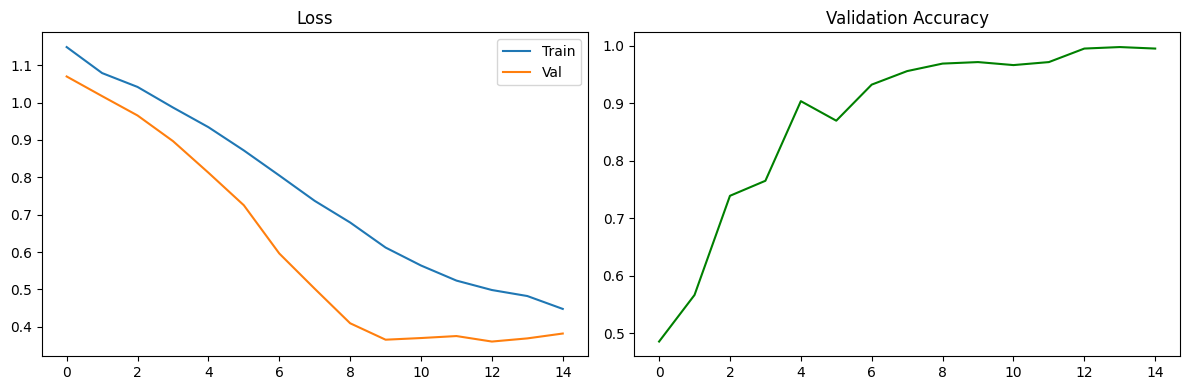


── Test Set Report ────────────────────────────────────
              precision    recall  f1-score   support

    negative       1.00      0.99      0.99       153
     neutral       0.99      1.00      0.99       147
    positive       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



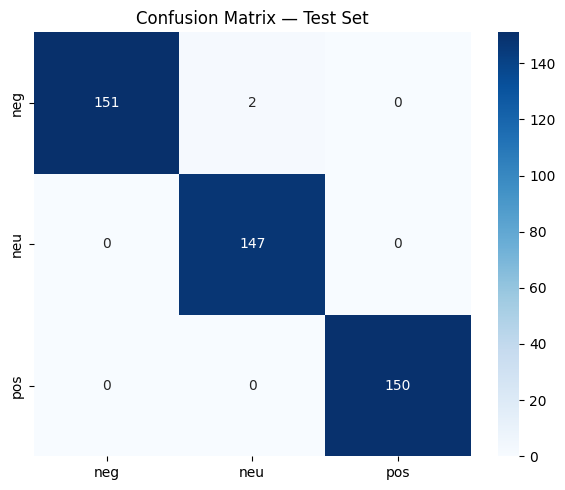

Model saved → sentiment_transformer.pt

── Inference Demo ──────────────────────────────────────
  tokens=['great', 'excellent', 'amazing', 'product']...  →  positive (76.12%)
    probs: {'negative': 0.1247, 'neutral': 0.1141, 'positive': 0.7612}
  tokens=['terrible', 'awful', 'horrible', 'experience']...  →  negative (63.16%)
    probs: {'negative': 0.6316, 'neutral': 0.1297, 'positive': 0.2387}
  tokens=['okay', 'average', 'normal', 'fine']...  →  neutral (89.35%)
    probs: {'negative': 0.0773, 'neutral': 0.8935, 'positive': 0.0292}


In [11]:
def main():
    # ── Config ────────────────────────────────────────────────────────────
    MAX_LEN    = 128
    BATCH_SIZE = 64
    EPOCHS     = 15
    D_MODEL    = 128
    NUM_HEADS  = 4
    NUM_LAYERS = 3
    D_FF       = 512
    DROPOUT    = 0.1
    LR         = 3e-4
    MIN_FREQ   = 2
    DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {DEVICE}")
 
    # ── Load data ──────────────────────────────────────────────────────────
    df = load_your_dataset()
 
    # Normalise tokens column: accept list or space-separated string
    if df["tokens"].dtype == object and isinstance(df["tokens"].iloc[0], str):
        df["tokens"] = df["tokens"].apply(str.split)
 
    # Normalise label column: accept strings or ints
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    if df["sentiment"].dtype == object:
        df["label"] = df["sentiment"].map(label_map)
    else:
        df["label"] = df["sentiment"].astype(int)
 
    print(f"Dataset size: {len(df):,}")
    print(df["sentiment"].value_counts())
 
    # ── Train / val / test split ───────────────────────────────────────────
    train_df, test_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
    train_df, val_df  = train_test_split(train_df, test_size=0.15, stratify=train_df["label"], random_state=42)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
    # ── Vocabulary ─────────────────────────────────────────────────────────
    vocab = Vocabulary(min_freq=MIN_FREQ)
    vocab.build(train_df["tokens"].tolist())   # build on train ONLY
 
    # ── Datasets & DataLoaders ─────────────────────────────────────────────
    def make_loader(split_df, shuffle):
        ds = SentimentDataset(split_df["tokens"].tolist(), split_df["label"].tolist(), vocab, MAX_LEN)
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0, pin_memory=True)
 
    train_loader = make_loader(train_df, shuffle=True)
    val_loader   = make_loader(val_df,   shuffle=False)
    test_loader  = make_loader(test_df,  shuffle=False)
 
    # ── Model ──────────────────────────────────────────────────────────────
    model = SentimentTransformer(
        vocab_size=len(vocab),
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        d_ff=D_FF,
        max_len=MAX_LEN,
        num_classes=3,
        dropout=DROPOUT,
        pad_idx=0,
    )
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model parameters: {total_params:,}")
 
    # ── Training ───────────────────────────────────────────────────────────
    trainer = Trainer(model, DEVICE, lr=LR)
    trainer.fit(train_loader, val_loader, epochs=EPOCHS)
    trainer.plot_history()
 
    # ── Test evaluation ────────────────────────────────────────────────────
    labels, preds = trainer.evaluate(test_loader)
    print("\n── Test Set Report ────────────────────────────────────")
    print(classification_report(labels, preds, target_names=["negative", "neutral", "positive"]))
 
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["neg", "neu", "pos"],
                yticklabels=["neg", "neu", "pos"])
    plt.title("Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
 
    # ── Save model ─────────────────────────────────────────────────────────
    torch.save({
        "model_state_dict": model.state_dict(),
        "vocab_token2idx":  vocab.token2idx,
        "config": dict(
            vocab_size=len(vocab), d_model=D_MODEL, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, d_ff=D_FF, max_len=MAX_LEN,
            num_classes=3, dropout=DROPOUT, pad_idx=0,
        ),
    }, "sentiment_transformer.pt")
    print("Model saved → sentiment_transformer.pt")
 
    # ── Quick inference demo ───────────────────────────────────────────────
    predictor = SentimentPredictor(model, vocab, MAX_LEN, DEVICE)
 
    samples = [
        ["great", "excellent", "amazing", "product"],
        ["terrible", "awful", "horrible", "experience"],
        ["okay", "average", "normal", "fine"],
    ]
    print("\n── Inference Demo ──────────────────────────────────────")
    for s in samples:
        result = predictor.predict(s)
        print(f"  tokens={s[:4]}...  →  {result['label']} ({result['confidence']:.2%})")
        print(f"    probs: {result['probs']}")
 
 
# ─────────────────────────────────────────────
# HOW TO LOAD A SAVED MODEL
# ─────────────────────────────────────────────
def load_model(path: str, device=None):
    device = device or torch.device("cpu")
    ckpt = torch.load(path, map_location=device)
 
    vocab = Vocabulary()
    vocab.token2idx = ckpt["vocab_token2idx"]
    vocab.idx2token = {v: k for k, v in vocab.token2idx.items()}
 
    model = SentimentTransformer(**ckpt["config"])
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
 
    return model, vocab
 
 
if __name__ == "__main__":
    main()
 